In [1]:
import os
import numpy as np
import scipy.io as sio
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import ancillary as ac
from sklearn.svm import LinearSVC
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import hdmedians as hd
from utils import correlation, calculate_mcc, age_regression, sex_classification, sz_classification, plot_sq, convert_pvalue, pvalue_to_r
from scipy import stats
from scipy.stats import pearsonr

In [2]:
res_dir = "/data/users4/xli/MSIVA/MSIVA/results"
sz_smri_data_path = os.path.join(res_dir, "mat", "mancovaOuts_allHCSZ_combinedRelatives_wX_preregSite_C30_SMRI_GICAinit.mat")
sz_smri_data = sio.loadmat(sz_smri_data_path)['NMODELHCSZ0ns']
sz_smri_data_array = sz_smri_data[0][0][0]
age = sz_smri_data_array[:,0]
sex = sz_smri_data_array[:,1]
diagnosis = sz_smri_data_array[:,2]
id = sio.loadmat(os.path.join(res_dir, "mat", "SZID.mat"))['ID'][0] - 1

In [ ]:
img_dir = os.path.join(res_dir, "img")
subspace_struct_list = ["s1", "s2", "s3", "s4", "s5"]
num_subspace_struct = len(subspace_struct_list)

Y = np.zeros((num_subspace_struct,3,2,12,999)) # S1-4, UA/MSIVA/GICA, M1-2, voxel, source
W = np.zeros((num_subspace_struct,3,2,12,44318)) # S1-4, UA/MSIVA/GICA, M1-2, voxel, source

num_iter = 21
corr = np.zeros((num_subspace_struct,9,12,12))

for i,ss in enumerate(subspace_struct_list):

    data = sio.loadmat(os.path.join(img_dir, ss, "um_neuroimaging_sz_Y.mat"))
    Y1 = np.squeeze(data['Y1'])

    data = sio.loadmat(os.path.join(img_dir, ss, "ummm_neuroimaging_sz_Y.mat"))
    Y2 = np.squeeze(data['Y2'])

    data = sio.loadmat(os.path.join(img_dir, ss, "mm_neuroimaging_sz_Y.mat"))
    Y3 = np.squeeze(data['Y3'])

    Y[i,0,0] = Y1[0][:,id]
    Y[i,0,1] = Y1[1][:,id]
    Y[i,1,0] = Y2[0][:,id]
    Y[i,1,1] = Y2[1][:,id]
    Y[i,2,0] = Y3[0][:,id]
    Y[i,2,1] = Y3[1][:,id]

    # for j in range(2):
    #     for k in range(2):
    #         for l in range(12):
    #             sgn = np.sign(correlation(Y[i,j,k,l],age))
    #             Y[i,j,k,l] = -sgn * Y[i,j,k,l]

    data = sio.loadmat(os.path.join(img_dir, ss, "um_neuroimaging_sz_W.mat"))
    W1 = np.squeeze(data['W1'])

    data = sio.loadmat(os.path.join(img_dir, ss, "ummm_neuroimaging_sz_W.mat"))
    W2 = np.squeeze(data['W2'])

    data = sio.loadmat(os.path.join(img_dir, ss, "mm_neuroimaging_sz_W.mat"))
    W3 = np.squeeze(data['W3'])

    W[i,0,0] = W1[0]
    W[i,0,1] = W1[1]
    W[i,1,0] = W2[0]
    W[i,1,1] = W2[1]
    W[i,2,0] = W3[0]
    W[i,2,1] = W3[1]

    corr[i,0] = np.corrcoef(Y1[0],Y1[0])[:12,:12]
    corr[i,1] = np.corrcoef(Y1[1],Y1[1])[:12,:12]
    corr[i,2] = np.corrcoef(Y1[0],Y1[1])[12:,:12]

    corr[i,3] = np.corrcoef(Y2[0],Y2[0])[:12,:12]
    corr[i,4] = np.corrcoef(Y2[1],Y2[1])[:12,:12]
    corr[i,5] = np.corrcoef(Y2[0],Y2[1])[12:,:12]

    corr[i,6] = np.corrcoef(Y3[0],Y3[0])[:12,:12]
    corr[i,7] = np.corrcoef(Y3[1],Y3[1])[:12,:12]
    corr[i,8] = np.corrcoef(Y3[0],Y3[1])[12:,:12]

In [4]:
val = 1
num_source = 12

# S1
num_unique_source = 3
s1 = np.zeros((num_source, num_source))
s1[:2,:2] = val
s1[2:5,2:5] = val*2
s1[5:9,5:9] = val*3

# S2
num_unique_source = 2
s2 = np.zeros((num_source, num_source))
s2[:2,:2] = val
s2[2:4,2:4] = val*2
s2[4:6,4:6] = val*3
s2[6:8,6:8] = val*4
s2[8:10,8:10] = val*5

# S3
num_unique_source = 3
s3 = np.zeros((num_source, num_source))
s3[:3,:3] = val
s3[3:6,3:6] = val*2
s3[6:9,6:9] = val*3

# S4
num_unique_source = 4
s4 = np.zeros((num_source, num_source))
s4[:4,:4] = val
s4[4:8,4:8] = val*2

# S5
num_unique_source = 4
s5 = np.zeros((num_source, num_source))
for i in range(12):
    s5[i,i] = val*(i+1)

s_list = [s1, s2, s3, s4, s5]

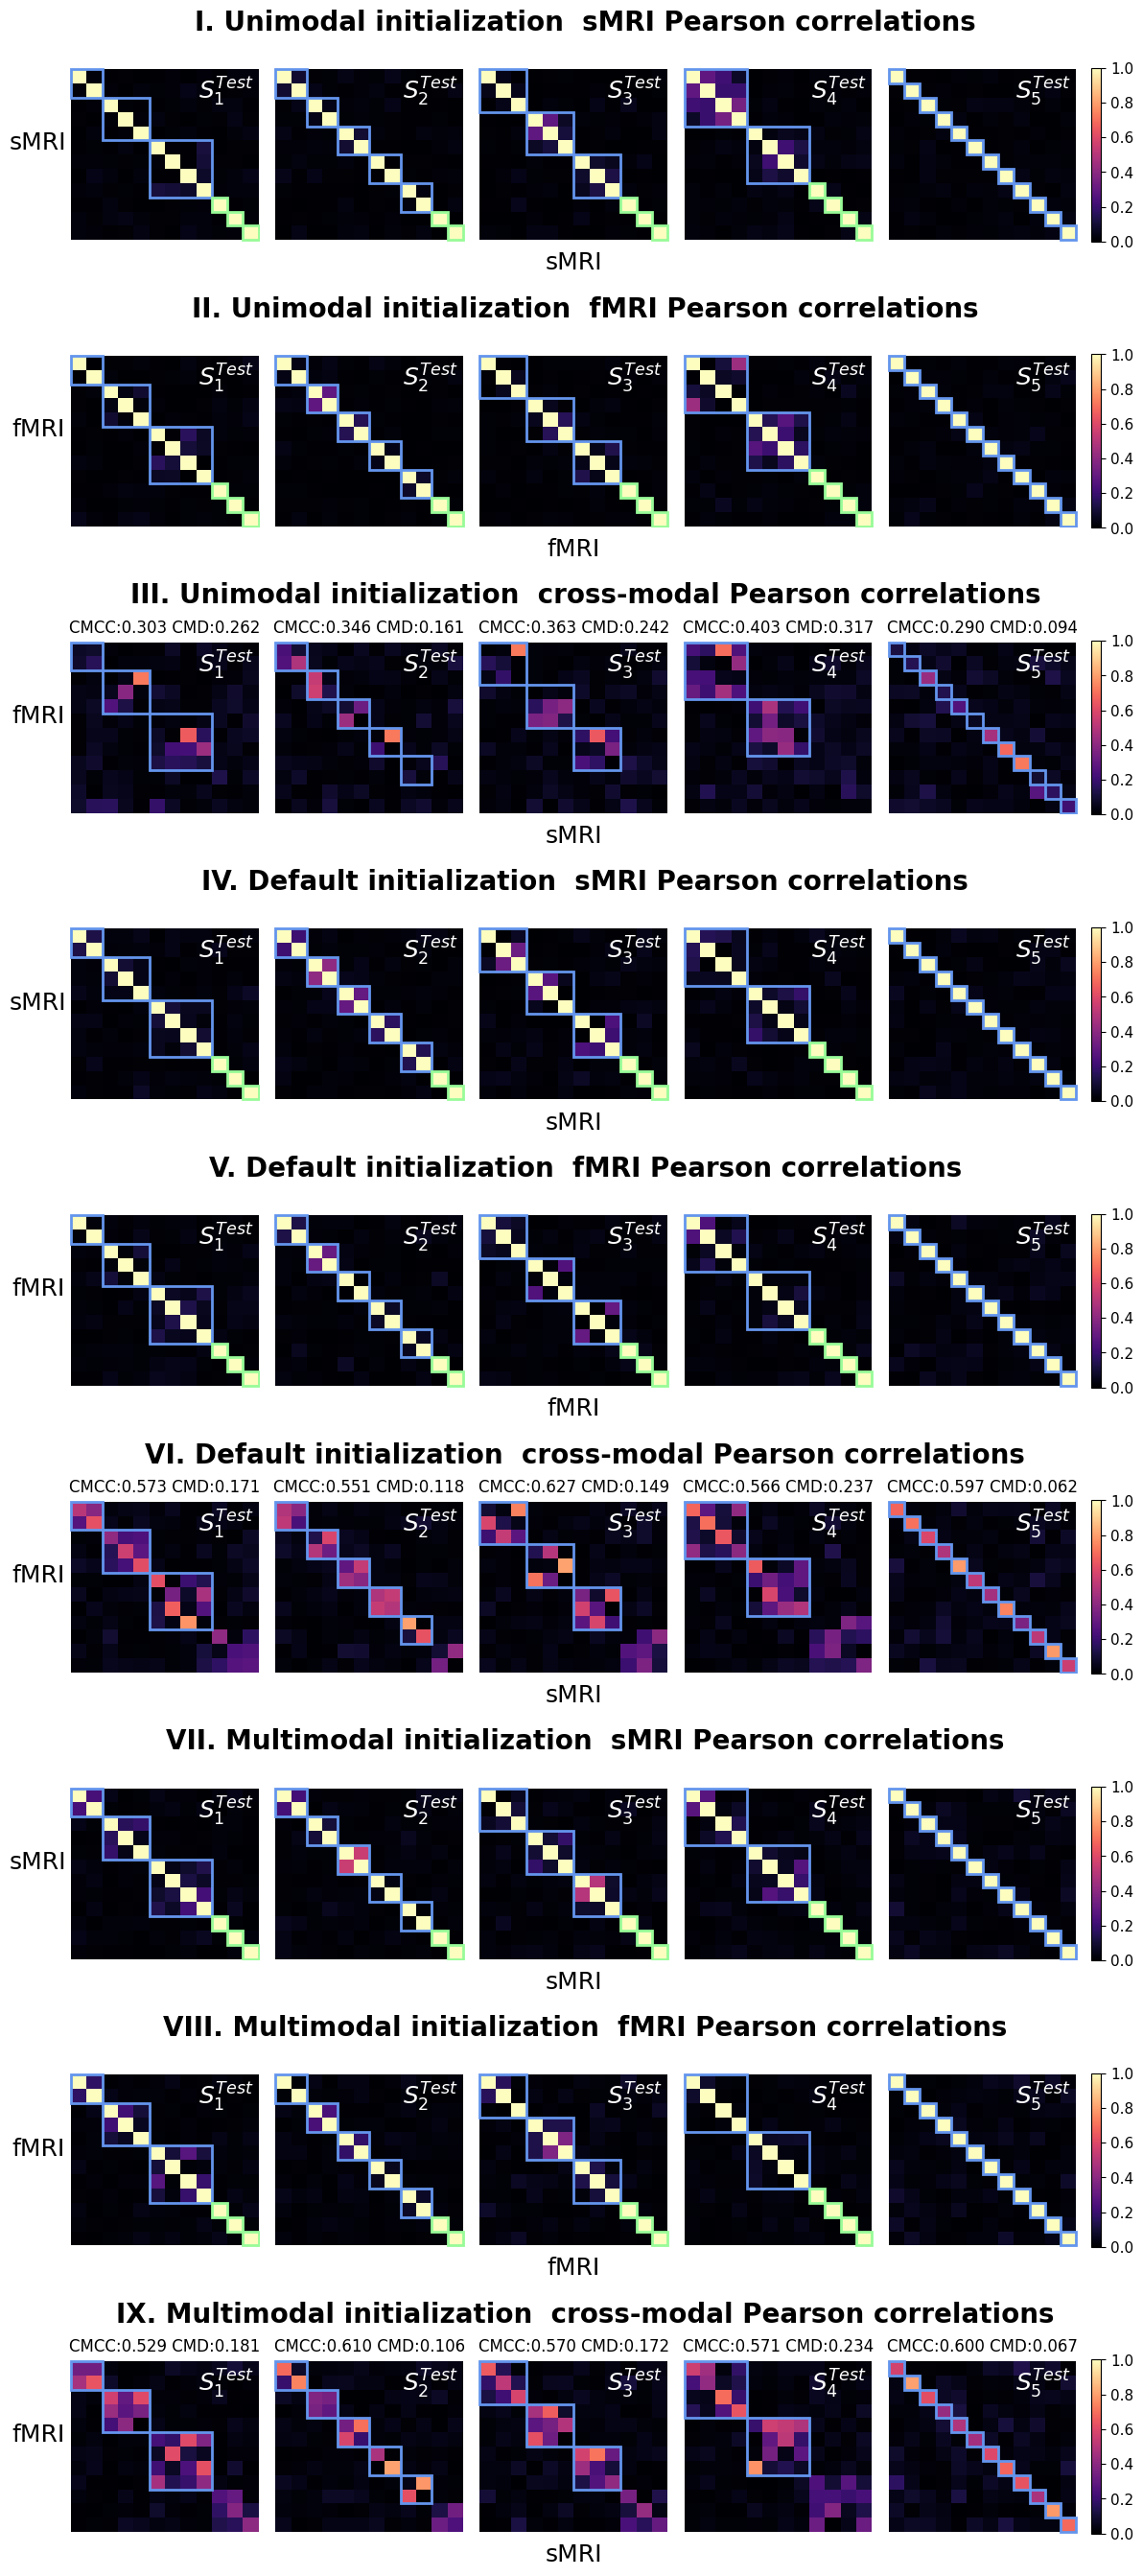

In [ ]:
analysis_list = ["I. Unimodal initialization  sMRI Pearson correlations",
                 "II. Unimodal initialization  fMRI Pearson correlations",
                 "III. Unimodal initialization  cross-modal Pearson correlations",
                 "IV. Default initialization  sMRI Pearson correlations",
                 "V. Default initialization  fMRI Pearson correlations",
                 "VI. Default initialization  cross-modal Pearson correlations",
                 "VII. Multimodal initialization  sMRI Pearson correlations",
                 "VIII. Multimodal initialization  fMRI Pearson correlations",
                 "IX. Multimodal initialization  cross-modal Pearson correlations"]
modality_list = ["sMRI", "fMRI"]
subspace_dict = {"S1": [2, 3, 4], "S2": [2, 2, 2, 2, 2], "S3": [3, 3, 3], "S4": [4, 4], "S5": [1]*12}

n_row = 9

fig, axes = plt.subplots(n_row, num_subspace_struct + 1, figsize = (2.4 * num_subspace_struct, 3 * n_row), gridspec_kw = {'width_ratios': [1, 1, 1, 1, 1, 0.05]})

for i in range(num_subspace_struct):
    ss = subspace_dict[f"S{i+1}"]
    for j in range(n_row):
        ax = axes[j,i]
        abscorr = np.abs(corr[i,j])
        if j in [2, 5, 8]:
            mcc, md, aggcorr, _ = calculate_mcc(abscorr, ss, sort=False)
            sns.heatmap(abscorr, cmap="magma", vmin=0, vmax=1, ax=ax, cbar=False)
            ax.text(9.9, 1.6, f"$S_{i+1}^{{Test}}$", fontsize=18, color="white", ha="center", va="center")
            ax.set_title(f"CMCC:{mcc:.3f} CMD:{md:.3f}", fontsize=12)
            if i == 2:
              ax.set_xlabel("sMRI", fontsize=18)
            if i == 0:
              ax.set_ylabel("fMRI", fontsize=18, rotation=0, labelpad=20)
            plot_sq(ax, i, crossmodal=True)
            ax.set_xlim(-0.1, 12.1)
            ax.set_ylim(12.1, -0.1)
        else:
            mcc = np.mean(np.diag(abscorr))
            sns.heatmap(abscorr, cmap="magma", vmin=0, vmax=1, ax=ax, cbar=False)
            ax.text(9.9, 1.6, f"$S_{i+1}^{{Test}}$", fontsize=18, color="white", ha="center", va="center")
            if i == 2:
               ax.set_xlabel(f"{modality_list[j%3]}", fontsize=18)
            if i == 0:
              ax.set_ylabel(f"{modality_list[j%3]}", fontsize=18, rotation=0, labelpad=20)
            plot_sq(ax, i)
            ax.set_xlim(-0.1, 12.1)
            ax.set_ylim(12.1, -0.1)
        ax.set_xticks([])
        ax.set_yticks([])

norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap="magma", norm=norm)

for i in range(n_row):
    ax = fig.add_subplot(n_row, 1, i+1)
    ax.set_title(analysis_list[i], fontsize=20, fontweight='bold', pad=28)
    ax.axis('off')
    cbar = fig.colorbar(sm, cax=axes[i, 5])
    cbar.ax.tick_params(labelsize=11)

plt.tight_layout(pad=1, h_pad=0, w_pad=1)
plt.savefig("figures/neuroimaging_sz.pdf")

In [6]:
A = sio.loadmat(os.path.join(res_dir, "mat", "A_sz.mat"))["A"]

WAY_list = []
cca_corr_list = []

for i in np.arange(0,10,2):
    # S1-4, UA/MSIVA, M1-2, voxel, source
    A1 = A[1,1,0,:,i:i+2] # structure 2, MSIVA, M1
    A2 = A[1,1,1,:,i:i+2] # structure 2, MSIVA, M2

    Y1 = Y[1,1,0,i:i+2] 
    Y2 = Y[1,1,1,i:i+2] 

    AY1 = A1@Y1
    AY2 = A2@Y2

    # PCA AY1, AY2
    AY1_p, AY1_p_projM, AY1_p_projM_std = ac.base_PCA(AY1, num_PC=None, axis=-2, whitening=True)
    AY2_p, AY2_p_projM, AY2_p_projM_std = ac.base_PCA(AY2, num_PC=None, axis=-2, whitening=True)

    # Post-PCA eigenvalue problem for CCA
    S12 = AY1_p @ AY2_p.T
    Z1 = np.zeros((AY1_p.shape[0],AY1_p.shape[0]), dtype=AY1_p.dtype)
    Z2 = np.zeros((AY2_p.shape[0],AY2_p.shape[0]), dtype=AY2_p.dtype)
    J = np.block([[Z1, S12],[S12.T, Z2]])
    U, S = ac.do_cov_EVD(J, k=2) # here, k = smallest subspace size in each modality

    # Final transformations: these multiply AY
    W1 = U[:2,].T @ AY1_p_projM
    W2 = U[2:,].T @ AY2_p_projM

    WAY1 = W1 @ AY1
    WAY2 = W2 @ AY2
    WAY_list.append( [WAY1, WAY2] )

    cca_corr = np.corrcoef(WAY1, WAY2)[2:,0:2]
    cca_corr_list.append(cca_corr)

In [7]:
num_voxel = A.shape[3]
num_crossmodal_subspace = 5
voxelwise_cca_corr = np.zeros((num_crossmodal_subspace, num_voxel))

for j, i in enumerate(np.arange(0,10,2)):
    A1 = A[1,1,0,:,i:i+2] # structure 2, MSIVA, M1
    A2 = A[1,1,1,:,i:i+2] # structure 2, MSIVA, M2
    Y1 = Y[1,1,0,i:i+2] 
    Y2 = Y[1,1,1,i:i+2] 
    AY1 = A1@Y1
    AY2 = A2@Y2
    for k in range(num_voxel):
        AY1_voxel = np.expand_dims(AY1[k, :], axis=0)
        AY2_voxel = np.expand_dims(AY2[k, :], axis=0)

        # PCA AY1, AY2
        AY1_p, AY1_p_projM, AY1_p_projM_std = ac.base_PCA(AY1_voxel, num_PC=None, axis=-2, whitening=True)
        AY2_p, AY2_p_projM, AY2_p_projM_std = ac.base_PCA(AY2_voxel, num_PC=None, axis=-2, whitening=True)

        # Post-PCA eigenvalue problem for CCA
        S12 = AY1_p @ AY2_p.T
        Z1 = np.zeros((AY1_p.shape[0],AY1_p.shape[0]), dtype=AY1_p.dtype)
        Z2 = np.zeros((AY2_p.shape[0],AY2_p.shape[0]), dtype=AY2_p.dtype)
        J = np.block([[Z1, S12], [S12.T, Z2]])
        U, S = ac.do_cov_EVD(J, k=2) # here, k = smallest subspace size in each modality

        # Final transformations: these multiply AY
        W1 = U[:1,].T @ AY1_p_projM
        W2 = U[1:,].T @ AY2_p_projM
        WAY1 = W1 @ AY1_voxel
        WAY2 = W2 @ AY2_voxel
        voxelwise_cca_corr[j, k] = np.corrcoef(WAY1, WAY2)[2:,0:2][0,0]

# sio.savemat("voxelwise_cca_corr_sz.mat", {"corr": voxelwise_cca_corr})

In [8]:
regularizer_range = np.linspace(0.1, 1, 10)
param_grid_rr = [{'alpha': regularizer_range}]
param_grid_svm = [{'C': regularizer_range}]

age_mae = np.zeros(5)
age_coef = np.zeros((5, 4))
diagnosis_acc = np.zeros(5)
diagnosis_coef = np.zeros((5, 4))
sex_acc = np.zeros(5)
sex_coef = np.zeros((5, 4))

for i in range(5):
    X12 = (np.concatenate((WAY_list[i][0], WAY_list[i][1]), axis=0)).T

    age_subset = age[age>15] # there is only one subject with age 15 and it can't be stratified
    X12_subset = X12[age>15, :]
    X_train, X_test, y_train, y_test = train_test_split(X12_subset, age_subset, test_size=0.3, random_state=42, stratify=age_subset)
    X_train = np.concatenate([X_train, X12[age==15, :]], axis=0)
    y_train = np.concatenate([y_train, np.array([15])], axis=0)
    base_estimator = Ridge()
    rr = GridSearchCV(base_estimator, param_grid_rr, cv=10).fit(X_train, y_train)
    mae, coef = age_regression(X_train, X_test, y_train, y_test, a=rr.best_params_['alpha'])
    age_mae[i] = mae
    age_coef[i] = coef

    X12_subset = X12[diagnosis<2, :]
    diagnosis_subset = diagnosis[diagnosis < 2]
    X_train, X_test, y_train, y_test = train_test_split(X12_subset, diagnosis_subset, test_size=0.3, random_state=42, stratify=diagnosis_subset)
    base_estimator = LinearSVC(dual=False)
    svc = GridSearchCV(base_estimator, param_grid_svm, cv=10).fit(X_train, y_train)
    acc, coef = sz_classification(X_train, X_test, y_train, y_test, c=svc.best_params_['C'])
    diagnosis_acc[i] = acc*100
    diagnosis_coef[i] = coef[0]

    X_train, X_test, y_train, y_test = train_test_split(X12, sex, test_size=0.3, random_state=42, stratify=sex)
    base_estimator = LinearSVC(dual=False)
    svc = GridSearchCV(base_estimator, param_grid_svm, cv=10).fit(X_train, y_train)
    acc, coef = sex_classification(X_train, X_test, y_train, y_test, c=svc.best_params_['C'])
    sex_acc[i] = acc*100
    sex_coef[i] = coef[0]

    print(f"Subspace {i+1}: age regression MAE {age_mae[i]:.3f}, diagnosis classification accuracy {diagnosis_acc[i]:.3f}, sex classification accuracy {sex_acc[i]:.3f}")

Subspace 1: age regression MAE 10.720, diagnosis classification accuracy 50.565, sex classification accuracy 49.468
Subspace 2: age regression MAE 10.470, diagnosis classification accuracy 57.624, sex classification accuracy 50.180
Subspace 3: age regression MAE 11.226, diagnosis classification accuracy 50.000, sex classification accuracy 50.000
Subspace 4: age regression MAE 11.445, diagnosis classification accuracy 49.691, sex classification accuracy 50.000
Subspace 5: age regression MAE 10.307, diagnosis classification accuracy 61.404, sex classification accuracy 50.000


/home/users/xli77/anaconda3/envs/icebeem/lib/python3.7/site-packages/ipykernel_launcher.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


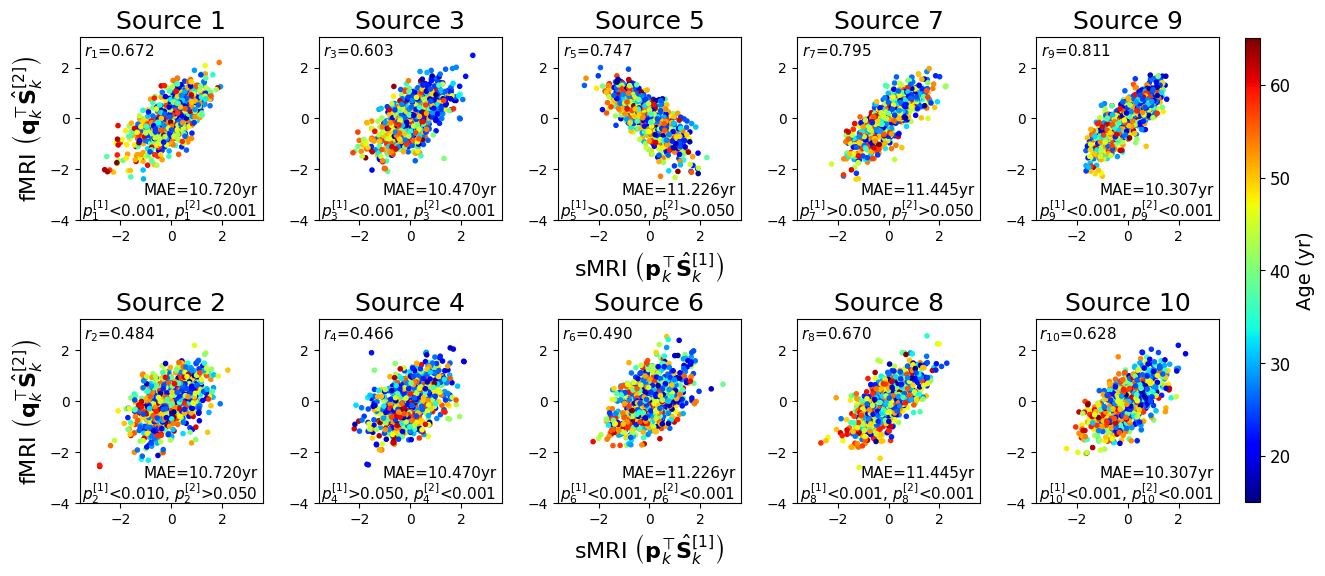

In [ ]:
num_subject = len(age)
age_median = np.median(age)

cmap = plt.cm.jet
norm = Normalize(vmin=age.min(), vmax=age.max())

lim = 3.6
fig, axes = plt.subplots(2,5,figsize=(12.5,5.8))

for k in range(5):
    for i in range(2):
        WAY1 = WAY_list[k][0]
        WAY2 = WAY_list[k][1]
        sign1 = np.sign(correlation(WAY1,age))
        sign2 = np.sign(correlation(WAY2,age))
        for j in range(2):
            WAY1[j,:] = -sign1[j]*WAY1[j,:]
            WAY2[j,:] = -sign2[j]*WAY2[j,:]
        axes[i,k].set_aspect('equal', 'box')
        if k == 2:
            axes[i,k].set_xlabel('sMRI $\\left(\mathbf{{p}}_k^\\top \hat{\mathbf{S}}_k^{[1]}\\right)$', fontsize=16)
        if k == 0:
            axes[i,k].set_ylabel('fMRI $\\left(\mathbf{{q}}_k^\\top \hat{\mathbf{S}}_k^{[2]}\\right)$', fontsize=16)
        axes[i,k].set_title(f'Source {2*k+i+1}', fontsize=18)
        axes[i,k].set_xlim([-lim,lim])
        axes[i,k].set_ylim([-lim-0.4,lim-0.4])
        r = format(round(cca_corr_list[k][i,i],3), '.3f')
        stat1, p1 = stats.ttest_ind(WAY1[i][age<age_median], WAY1[i][age>=age_median])
        stat2, p2 = stats.ttest_ind(WAY2[i][age<age_median], WAY2[i][age>=age_median])
        p1_str = convert_pvalue(p1*20)
        p2_str = convert_pvalue(p2*20)
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$r_{{10}}$={r}', xy=(58, 128), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$r_{2*k+i+1}$={r}', xy=(54, 128), xycoords='axes points', size=11, ha='right', va='top')
        axes[i,k].annotate(f'MAE={age_mae[k]:.3f}yr', xy=(128, 27), xycoords='axes points', size=11, ha='right', va='top')
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$p^{{[1]}}_{{10}}${p1_str}, $p^{{[2]}}_{{10}}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$p^{{[1]}}_{2*k+i+1}${p1_str}, $p^{{[2]}}_{2*k+i+1}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        age_subplot = axes[i,k].scatter(WAY1[i], WAY2[i], c=age, cmap=cmap, norm=norm, marker='.', alpha=1)

cbar_ax = fig.add_axes([1, 0.13, 0.012, 0.8])
cbar = plt.colorbar(age_subplot, cax=cbar_ax)
cbar.set_label('Age (yr)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("figures/cca_age_sz.png", bbox_inches='tight', dpi=2000)

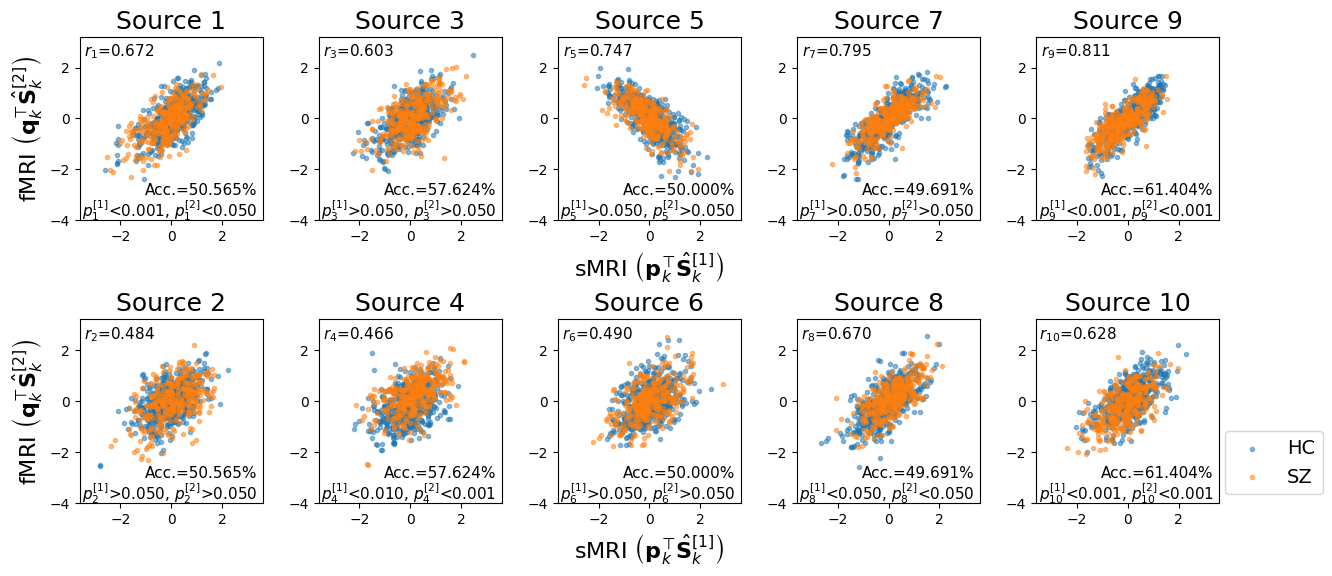

In [ ]:
lim = 3.6
fig, axes = plt.subplots(2,5,figsize=(12.5,5.8))

for k in range(5):
    for i in range(2):
        WAY1 = WAY_list[k][0]
        WAY2 = WAY_list[k][1]
        sign1 = np.sign(correlation(WAY1,age))
        sign2 = np.sign(correlation(WAY2,age))
        for j in range(2):
            WAY1[j,:] = -sign1[j]*WAY1[j,:]
            WAY2[j,:] = -sign2[j]*WAY2[j,:]
        axes[i,k].set_aspect('equal', 'box')
        if k == 2:
            axes[i,k].set_xlabel('sMRI $\\left(\mathbf{{p}}_k^\\top \hat{\mathbf{S}}_k^{[1]}\\right)$', fontsize=16)
        if k == 0:
            axes[i,k].set_ylabel('fMRI $\\left(\mathbf{{q}}_k^\\top \hat{\mathbf{S}}_k^{[2]}\\right)$', fontsize=16)
        axes[i,k].set_title(f'Source {2*k+i+1}', fontsize=18)
        axes[i,k].set_xlim([-lim,lim])
        axes[i,k].set_ylim([-lim-0.4,lim-0.4])
        r = format(round(cca_corr_list[k][i,i],3), '.3f')
        stat1, p1 = stats.ttest_ind(WAY1[i][diagnosis==0], WAY1[i][diagnosis==1])
        stat2, p2 = stats.ttest_ind(WAY2[i][diagnosis==0], WAY2[i][diagnosis==1])
        p1_str = convert_pvalue(p1*20) # correct for number of subjects
        p2_str = convert_pvalue(p2*20)
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$r_{{10}}$={r}', xy=(58, 128), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$r_{2*k+i+1}$={r}', xy=(54, 128), xycoords='axes points', size=11, ha='right', va='top')
        axes[i,k].annotate(f'Acc.={diagnosis_acc[k]:.3f}%', xy=(128, 27), xycoords='axes points', size=11, ha='right', va='top')
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$p^{{[1]}}_{{10}}${p1_str}, $p^{{[2]}}_{{10}}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$p^{{[1]}}_{2*k+i+1}${p1_str}, $p^{{[2]}}_{2*k+i+1}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        if k==0 and i==0:
            axes[i,k].scatter(WAY1[i,diagnosis==0], WAY2[i,diagnosis==0],color=sns.color_palette("tab10")[0],marker='.',alpha=0.5,label="HC")
            axes[i,k].scatter(WAY1[i,diagnosis==1], WAY2[i,diagnosis==1],color=sns.color_palette("tab10")[1],marker='.',alpha=0.5,label="SZ")
        else:
            axes[i,k].scatter(WAY1[i,diagnosis==0], WAY2[i,diagnosis==0],color=sns.color_palette("tab10")[0],marker='.',alpha=0.5)
            axes[i,k].scatter(WAY1[i,diagnosis==1], WAY2[i,diagnosis==1],color=sns.color_palette("tab10")[1],marker='.',alpha=0.5)

fig.legend(bbox_to_anchor=(1.07, 0.27), fontsize=14)

plt.tight_layout()
plt.savefig("figures/cca_diag_sz.png", bbox_inches='tight', dpi=2000)

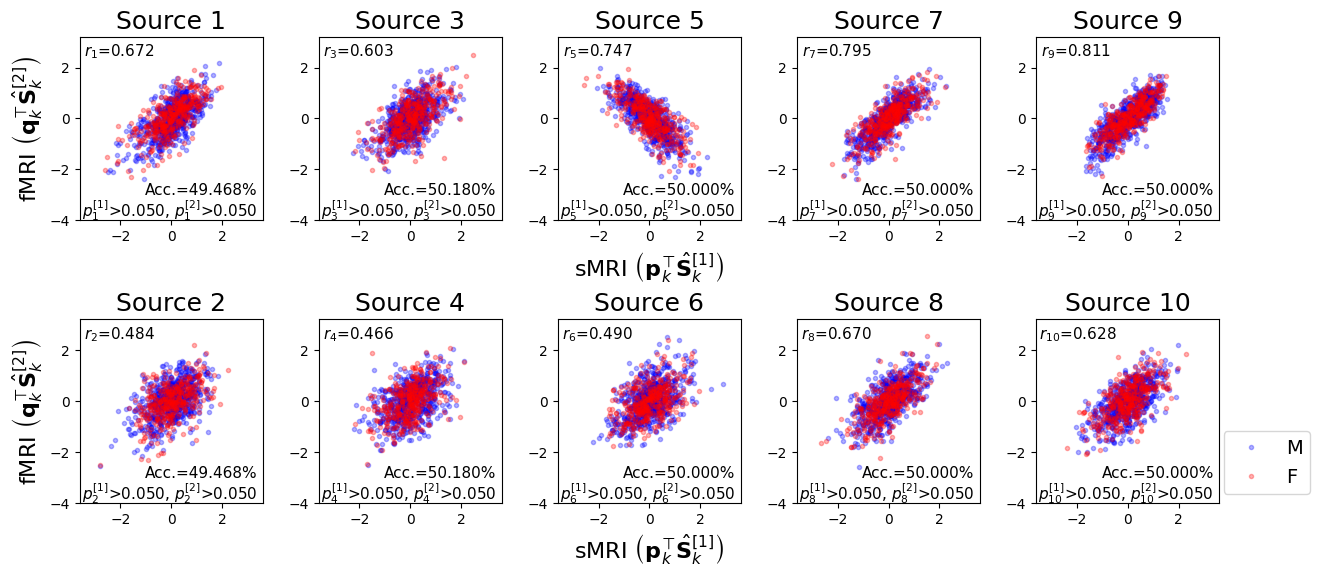

In [ ]:
lim = 3.6
fig, axes = plt.subplots(2,5,figsize=(12.5,5.8))

num_subject = len(age)

for k in range(5):
    for i in range(2):
        WAY1 = WAY_list[k][0]
        WAY2 = WAY_list[k][1]
        sign1 = np.sign(correlation(WAY1,age))
        sign2 = np.sign(correlation(WAY2,age))
        for j in range(2):
            WAY1[j,:] = -sign1[j]*WAY1[j,:]
            WAY2[j,:] = -sign2[j]*WAY2[j,:]
        axes[i,k].set_aspect('equal', 'box')
        if k == 2:
            axes[i,k].set_xlabel('sMRI $\\left(\mathbf{{p}}_k^\\top \hat{\mathbf{S}}_k^{[1]}\\right)$', fontsize=16)
        if k == 0:
            axes[i,k].set_ylabel('fMRI $\\left(\mathbf{{q}}_k^\\top \hat{\mathbf{S}}_k^{[2]}\\right)$', fontsize=16)
        axes[i,k].set_title(f'Source {2*k+i+1}', fontsize=18)
        axes[i,k].set_xlim([-lim,lim])
        axes[i,k].set_ylim([-lim-0.4,lim-0.4])
        r = format(round(cca_corr_list[k][i,i],3), '.3f')
        stat1, p1 = stats.ttest_ind(WAY1[i][sex==0], WAY1[i][sex==1])
        stat2, p2 = stats.ttest_ind(WAY2[i][sex==0], WAY2[i][sex==1])
        p1_str = convert_pvalue(p1*20) # correct for number of subjects
        p2_str = convert_pvalue(p2*20)
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$r_{{10}}$={r}', xy=(58, 128), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$r_{2*k+i+1}$={r}', xy=(54, 128), xycoords='axes points', size=11, ha='right', va='top')
        axes[i,k].annotate(f'Acc.={sex_acc[k]:.3f}%', xy=(128, 27), xycoords='axes points', size=11, ha='right', va='top')
        if k == 4 and i == 1:
            axes[i,k].annotate(f'$p^{{[1]}}_{{10}}${p1_str}, $p^{{[2]}}_{{10}}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        else:
            axes[i,k].annotate(f'$p^{{[1]}}_{2*k+i+1}${p1_str}, $p^{{[2]}}_{2*k+i+1}${p2_str}', xy=(128, 16), xycoords='axes points', size=11, ha='right', va='top')
        if k==0 and i==0:
            axes[i,k].plot(WAY1[i][sex==0], WAY2[i][sex==0],'b.',alpha=0.3,label='M')
            axes[i,k].plot(WAY1[i][sex==1], WAY2[i][sex==1],'r.',alpha=0.3,label='F')
        else:
            axes[i,k].plot(WAY1[i][sex==0], WAY2[i][sex==0],'b.',alpha=0.3)
            axes[i,k].plot(WAY1[i][sex==1], WAY2[i][sex==1],'r.',alpha=0.3)

fig.legend(bbox_to_anchor=(1.06, 0.27), fontsize=14)

plt.tight_layout()
plt.savefig("figures/cca_sex_sz.png", bbox_inches='tight', dpi=2000)

In [12]:
# M1-2, S1-5, median/young control/old control/young patient/old patient, voxel
age_median = np.median(age)
AY_median = np.zeros((2, 5, 5, 44318))
for s, i in enumerate(np.arange(0,10,2)):
    for m in range(2):
        Am = A[1,1,m,:,i:i+2]
        Ym = Y[1,1,m,i:i+2]
        AYm = Am@Ym
        AYm_young_hc = AYm[:,(age<age_median)&(diagnosis==0)]
        AYm_old_hc = AYm[:,(age>=age_median)&(diagnosis==0)]
        AYm_young_sz = AYm[:,(age<age_median)&(diagnosis==1)]
        AYm_old_sz = AYm[:,(age>=age_median)&(diagnosis==1)]
        AYm_median = hd.geomedian(AYm,axis=1)
        AYm_young_hc_median = hd.geomedian(AYm_young_hc,axis=1)
        AYm_old_hc_median = hd.geomedian(AYm_old_hc,axis=1)
        AYm_young_sz_median = hd.geomedian(AYm_young_sz,axis=1)
        AYm_old_sz_median = hd.geomedian(AYm_old_sz,axis=1)
        AY_median[m,s,0] = AYm_median
        AY_median[m,s,1] = AYm_young_hc_median
        AY_median[m,s,2] = AYm_old_hc_median
        AY_median[m,s,3] = AYm_young_sz_median
        AY_median[m,s,4] = AYm_old_sz_median
# sio.savemat(os.path.join(res_dir, "mat", "AY_median_sz_interaction.mat"), {"AY_median": AY_median})

In [13]:
# M1-2, S1-5, median/young control/old control/young patient/old patient, voxel
n_voxel = 44318
age_median = np.median(age)
AY_median = np.zeros((2, 5, 5, n_voxel))
for s, i in enumerate(np.arange(0,10,2)):
    A1 = A[1,1,0,:,i:i+2]
    Y1 = Y[1,1,0,i:i+2]
    A2 = A[1,1,1,:,i:i+2]
    Y2 = Y[1,1,1,i:i+2]
    AY1 = A1@Y1
    AY2 = A2@Y2
    AY = np.concatenate((AY1, AY2), axis=0)
    AYm_young_hc = AY[:,(age<age_median)&(diagnosis==0)]
    AYm_old_hc = AY[:,(age>=age_median)&(diagnosis==0)]
    AYm_young_sz = AY[:,(age<age_median)&(diagnosis==1)]
    AYm_old_sz = AY[:,(age>=age_median)&(diagnosis==1)]
    AYm_median = hd.geomedian(AY,axis=1)
    AYm_young_hc_median = hd.geomedian(AYm_young_hc,axis=1)
    AYm_old_hc_median = hd.geomedian(AYm_old_hc,axis=1)
    AYm_young_sz_median = hd.geomedian(AYm_young_sz,axis=1)
    AYm_old_sz_median = hd.geomedian(AYm_old_sz,axis=1)
    AY_median[0,s,0] = AYm_median[:n_voxel]
    AY_median[0,s,1] = AYm_young_hc_median[:n_voxel]
    AY_median[0,s,2] = AYm_old_hc_median[:n_voxel]
    AY_median[0,s,3] = AYm_young_sz_median[:n_voxel]
    AY_median[0,s,4] = AYm_old_sz_median[:n_voxel]
    AY_median[1,s,0] = AYm_median[n_voxel:]
    AY_median[1,s,1] = AYm_young_hc_median[n_voxel:]
    AY_median[1,s,2] = AYm_old_hc_median[n_voxel:]
    AY_median[1,s,3] = AYm_young_sz_median[n_voxel:]
    AY_median[1,s,4] = AYm_old_sz_median[n_voxel:]
# sio.savemat(os.path.join(res_dir, "mat", "stacked_AY_median_sz_interaction.mat"), {"AY_median": AY_median})

In [14]:
age_median = np.median(age)
AY_corr = np.zeros((5, 5, 44318))
p_value = np.zeros((5, 5, 44318))
for s, i in enumerate(np.arange(0,10,2)):
    A1 = A[1,1,0,:,i:i+2]
    Y1 = Y[1,1,0,i:i+2]
    A2 = A[1,1,1,:,i:i+2]
    Y2 = Y[1,1,1,i:i+2]
    AY1 = A1@Y1
    AY2 = A2@Y2
    for j in range(44318):
        AY_corr[s,0,j], p_value[s,0,j] = pearsonr(AY1[j], AY2[j])
        AY_corr[s,1,j], p_value[s,1,j] = pearsonr(AY1[j,(age<age_median)&(diagnosis==0)], AY2[j,(age<age_median)&(diagnosis==0)])
        AY_corr[s,2,j], p_value[s,2,j] = pearsonr(AY1[j,(age>=age_median)&(diagnosis==0)], AY2[j,(age>=age_median)&(diagnosis==0)])
        AY_corr[s,3,j], p_value[s,3,j] = pearsonr(AY1[j,(age<age_median)&(diagnosis==1)], AY2[j,(age<age_median)&(diagnosis==1)])
        AY_corr[s,4,j], p_value[s,4,j] = pearsonr(AY1[j,(age>=age_median)&(diagnosis==1)], AY2[j,(age>=age_median)&(diagnosis==1)])
# sio.savemat(os.path.join(res_dir, "mat", "AY_group_corr_sz_interaction.mat"), {"AY_corr": AY_corr})
# sio.savemat(os.path.join(res_dir, "mat", "AY_group_pvalue_sz_interaction.mat"), {"p_value": p_value})

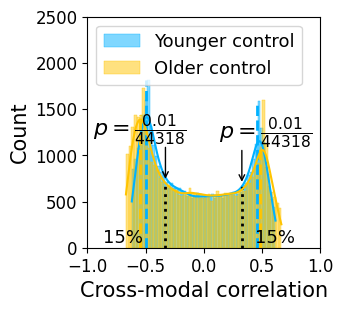

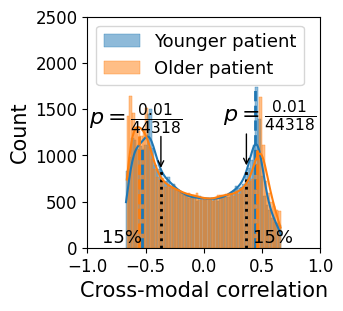

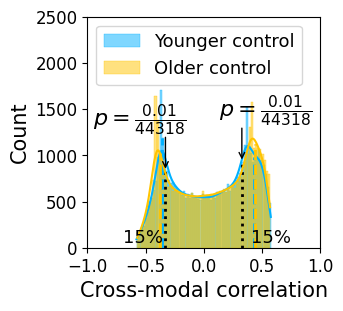

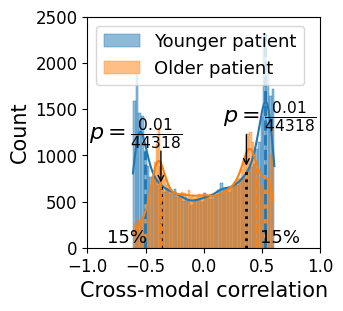

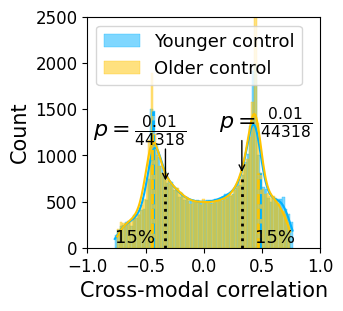

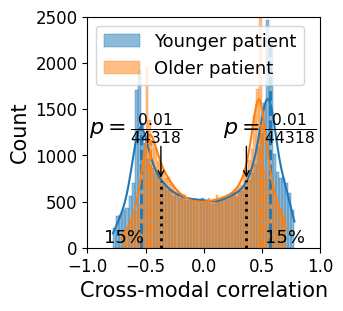

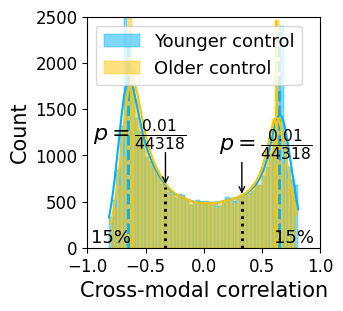

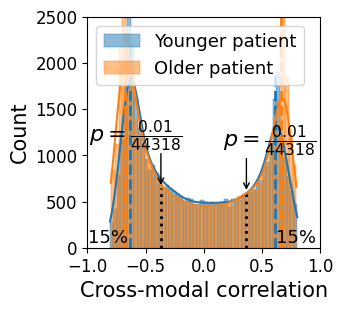

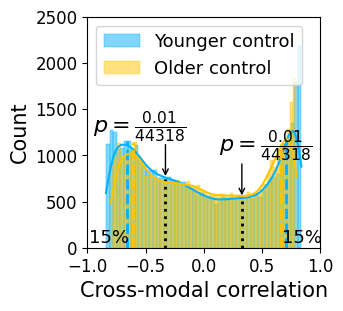

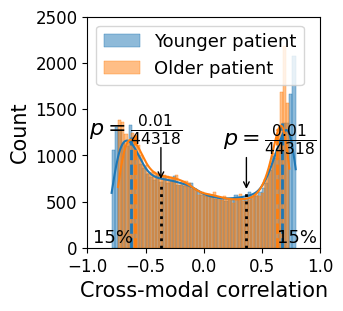

In [ ]:
# AY_corr = sio.loadmat("mat/AY_group_corr_sz_interaction.mat")["AY_corr"]

age_median = np.median(age)
n_young_control = np.sum((age<age_median)&(diagnosis==0))
n_old_control = np.sum((age>=age_median)&(diagnosis==0))
n_young_patient = np.sum((age<age_median)&(diagnosis==1))
n_old_patient = np.sum((age>=age_median)&(diagnosis==1))
n_list = [n_young_control, n_old_control, n_young_patient, n_old_patient]

cmap = plt.get_cmap('jet')
percentiles = [30, 70]
norm_percentiles = [p / 100.0 for p in percentiles]
colors = [cmap(norm) for norm in norm_percentiles]

title_list = ["All", "Younger control", "Older control", "Younger patient", "Older patient"]
group_list = ["control", "patient"]
color_list = [colors, [sns.color_palette("tab10")[0], sns.color_palette("tab10")[1]]]

for s in range(5):
    for i, j in enumerate([1,3]):
        fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        pct_neg, pct_pos, h_pct_neg, h_pct_pos = [], [], [], []
        for k in range(2):
            fd = 2*(np.percentile(AY_corr[s,j+k],75) - np.percentile(AY_corr[s,j+k],25))*len(AY_corr[s,j+k])**(-1/3)
            corr_range = np.max(AY_corr[s,j+k]) - np.min(AY_corr[s,j+k])
            num_bins = int(corr_range/(fd/2))
            counts, bins = np.histogram(AY_corr[s,j+k], bins=num_bins)
            hist_plot = sns.histplot(data=AY_corr[s,j+k], bins=num_bins, kde=True, color=color_list[i][k], edgecolor=color_list[i][k], label=title_list[j+k],ax=ax)
            
            pct = np.percentile(AY_corr[s,j+k], [15, 85])
            pct_neg.append(pct[0])
            pct_pos.append(pct[1])
            for q, p in enumerate(pct):
                ind = np.argmin(np.abs(bins - p))
                ax.vlines(p, 0, counts[ind], colors=color_list[i][k], linestyles='dashed', linewidth=2)
                if q == 0:
                    h_pct_neg.append(counts[ind])
                else:
                    h_pct_pos.append(counts[ind])
            
            if k == 0:
                thr_corr = pvalue_to_r(0.01/44318, n_list[j+k-1])
                ind = np.argmin(np.abs(bins - thr_corr))
                ax.vlines(thr_corr, 0, counts[ind], colors='k', linestyles='dotted', linewidth=2)
                ax.text(thr_corr-0.2, counts[ind]+500, "$p=\\frac{0.01}{44318}$", fontsize=16)
                ax.annotate("", xy=(thr_corr, counts[ind]), xytext=(thr_corr, counts[ind]+400), arrowprops=dict(arrowstyle="->"))

                ind = np.argmin(np.abs(bins + thr_corr))
                ax.vlines(-thr_corr, 0, counts[ind], colors='k', linestyles='dotted', linewidth=2)
                ax.text(-thr_corr-0.62, counts[ind]+500, "$p=\\frac{0.01}{44318}$", fontsize=16)
                ax.annotate("", xy=(-thr_corr, counts[ind]), xytext=(-thr_corr, counts[ind]+400), arrowprops=dict(arrowstyle="->"))

        ax.text(min(pct_neg)-0.32, 50, "15%", fontsize=13)
        ax.text(max(pct_pos)-0.04, 50, "15%", fontsize=13)
        
        # ax.set_title(f"Subspace {s+1}", fontsize=16)
        ax.set_xlabel("Cross-modal correlation", fontsize=15)
        ax.set_ylabel("Count", fontsize=15)
        ax.set_xlim([-1, 1])
        ax.set_ylim([0, 2500])
        ax.legend(loc="upper left", fontsize=13) # bbox_to_anchor=(0.92, 1.35)
        plt.tick_params(axis='both', labelsize=12)
        plt.savefig(f"figures/AY_histogram/sz/subspace{s+1}_{group_list[i]}.png", bbox_inches="tight", dpi=500)

In [17]:
Xpath = os.path.join(res_dir, "mat", "sMRI-fMRI", "X_sz.mat")
X = sio.loadmat(Xpath)['X']
X = np.squeeze(X)
X[0].shape

(44318, 1000)

In [18]:
AY_corr = np.zeros((5, 44318))
for m in range(2):
    Xm = X[m][:,id]
    Xm_demean = Xm - np.mean(Xm)
    sstot = np.sum(Xm_demean**2)
    for s, i in enumerate(np.arange(0,10,2)):
        Am = A[1,1,m,:,i:i+2]
        Ym = Y[1,1,m,i:i+2]
        AYm = Am@Ym
        ssres = np.sum((Xm-AYm)**2)
        r2 = (1 - ssres/sstot)*100
        print(f"modality {m+1} subspace {s+1} variance explained: {r2:.3f}%") 

modality 1 subspace 1 variance explained: 4.161%
modality 1 subspace 2 variance explained: 5.179%
modality 1 subspace 3 variance explained: 4.690%
modality 1 subspace 4 variance explained: 4.347%
modality 1 subspace 5 variance explained: 14.403%
modality 2 subspace 1 variance explained: 3.797%
modality 2 subspace 2 variance explained: 4.157%
modality 2 subspace 3 variance explained: 4.628%
modality 2 subspace 4 variance explained: 2.936%
modality 2 subspace 5 variance explained: 5.624%
